In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"C:\Users\igbhu\Desktop\Myntra Dataset.csv")
df.head(5)

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,04-Jun-18,Bhawna,Madhya Pradesh,Indore,523,204,7,Clothing,Trousers,COD
1,B-25757,21-Aug-18,Vishakha,Madhya Pradesh,Indore,211,19,8,Clothing,Stole,COD
2,B-25757,21-Aug-18,Vishakha,Madhya Pradesh,Indore,165,30,3,Clothing,Stole,COD
3,B-25703,28-Jun-18,Ekta,Madhya Pradesh,Indore,231,-190,9,Clothing,Hankerchief,COD
4,B-25703,28-Jun-18,Ekta,Madhya Pradesh,Indore,97,-45,4,Clothing,Saree,COD


In [3]:
df.shape

(1500, 11)

In [4]:
df.size

16500

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Order Date    1500 non-null   object
 2   CustomerName  1500 non-null   object
 3   State         1500 non-null   object
 4   City          1500 non-null   object
 5   Amount        1500 non-null   int64 
 6   Profit        1500 non-null   int64 
 7   Quantity      1500 non-null   int64 
 8   Category      1500 non-null   object
 9   Sub-Category  1500 non-null   object
 10  PaymentMode   1500 non-null   object
dtypes: int64(3), object(8)
memory usage: 129.0+ KB


In [6]:
df.describe

<bound method NDFrame.describe of      Order ID Order Date CustomerName           State       City  Amount  \
0     B-25681  04-Jun-18       Bhawna  Madhya Pradesh     Indore     523   
1     B-25757  21-Aug-18     Vishakha  Madhya Pradesh     Indore     211   
2     B-25757  21-Aug-18     Vishakha  Madhya Pradesh     Indore     165   
3     B-25703  28-Jun-18         Ekta  Madhya Pradesh     Indore     231   
4     B-25703  28-Jun-18         Ekta  Madhya Pradesh     Indore      97   
...       ...        ...          ...             ...        ...     ...   
1495  B-25725  20-Jul-18       Anisha        Nagaland     Kohima      26   
1496  B-25891  04-Dec-18      Shivani  Madhya Pradesh     Indore      25   
1497  B-26003  08-Feb-18       Hitesh  Madhya Pradesh     Bhopal      17   
1498  B-25723  18-Jul-18         Wale     Maharashtra     Mumbai      16   
1499  B-26070  18-Mar-18       Shruti       Karnataka  Bangalore      14   

      Profit  Quantity  Category Sub-Category Payment

In [7]:
df.isnull().sum()

Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
dtype: int64

In [8]:
df['profit_per_unit'] = df['Profit']/df['Quantity']

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [12]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

In [13]:
#TOTAL SALES
df['Amount'].sum()

np.int64(437771)

In [14]:
#category-wise-sales
df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

Category
Electronics    166267
Clothing       144323
Furniture      127181
Name: Amount, dtype: int64

In [15]:
#profit by category
df.groupby('Category')['Profit'].sum()

Category
Clothing       13325
Electronics    13162
Furniture      10476
Name: Profit, dtype: int64

In [16]:
#top states
df.groupby('State')['Amount'].sum().sort_values(ascending=False)

State
Maharashtra          102498
Madhya Pradesh        87463
Uttar Pradesh         38362
Delhi                 22957
Rajasthan             22334
Gujarat               21371
Punjab                16786
West Bengal           14328
Kerala                13871
Bihar                 13417
Andhra Pradesh        13256
Karnataka             12520
Nagaland              11993
Jammu and Kashmir     10829
Haryana                8863
Himachal Pradesh       8666
Goa                    6705
Tamil Nadu             6276
Sikkim                 5276
Name: Amount, dtype: int64

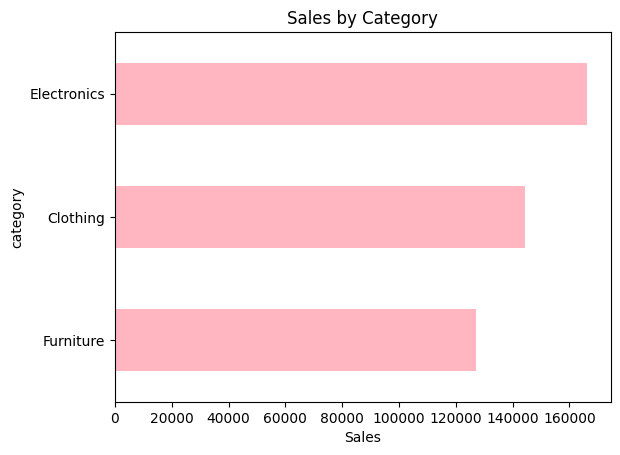

In [17]:
#Sales by Category (Bar Chart)
category_sales = df.groupby('Category')['Amount'].sum().sort_values()

category_sales.plot(kind='barh',color='lightpink') #horizontal graph
plt.title('Sales by Category')
plt.xlabel('Sales')
plt.ylabel('category')
plt.show()

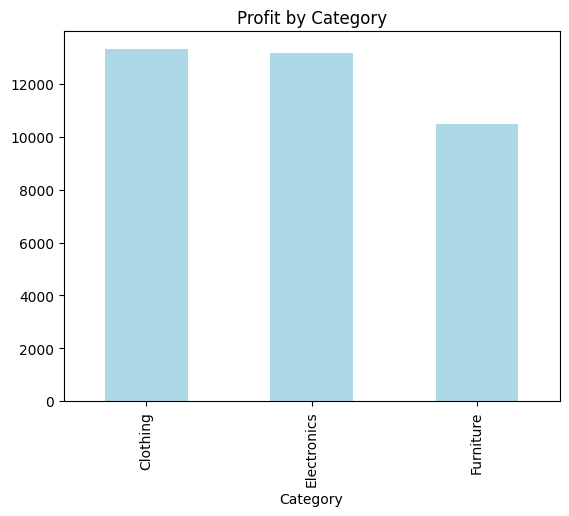

In [18]:
#Profit by Category
category_profit = df.groupby('Category')['Profit'].sum()

category_profit.plot(kind='bar',color='lightblue')
plt.title('Profit by Category')
plt.show()

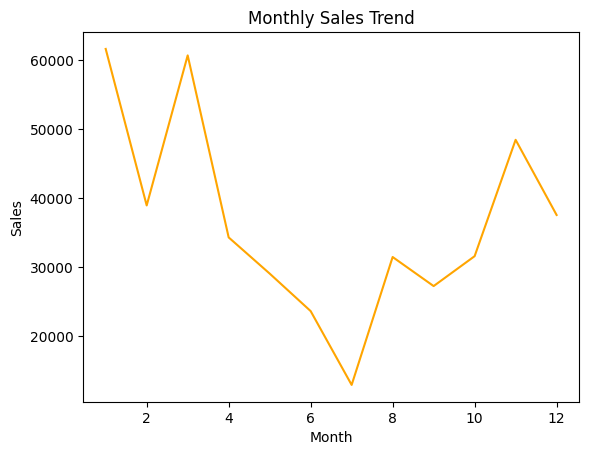

In [19]:
#Monthly Sales Trend
monthly_sales = df.groupby('Month')['Amount'].sum()

monthly_sales.plot(color='orange')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

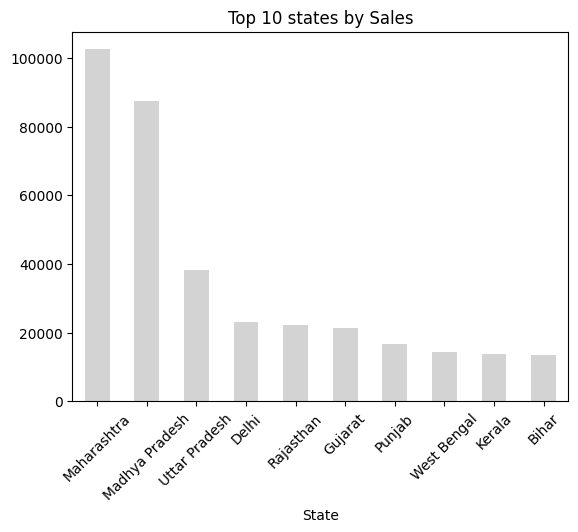

In [20]:
#Top 10 States by Sales
top_states = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar',color='lightgrey')
plt.title('Top 10 states by Sales')
plt.xticks(rotation=45)
plt.show()

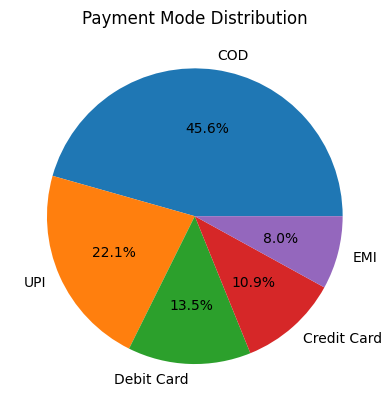

In [21]:
#Payment Mode Distribution
df['PaymentMode'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Mode Distribution')
plt.ylabel('')
plt.show()

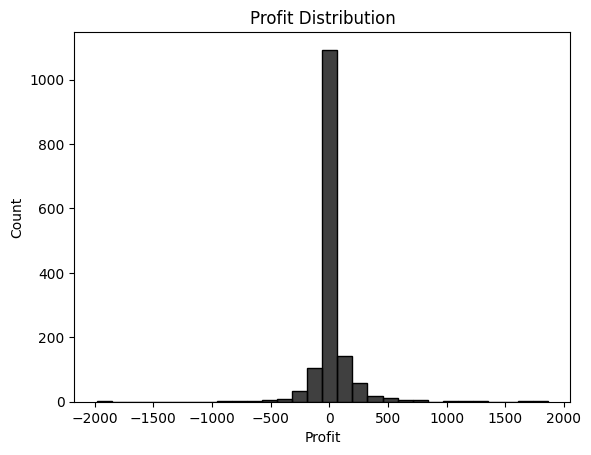

In [22]:
#Profit Distribution
sns.histplot(df['Profit'], bins=30, color='black')
plt.title('Profit Distribution')
plt.show()

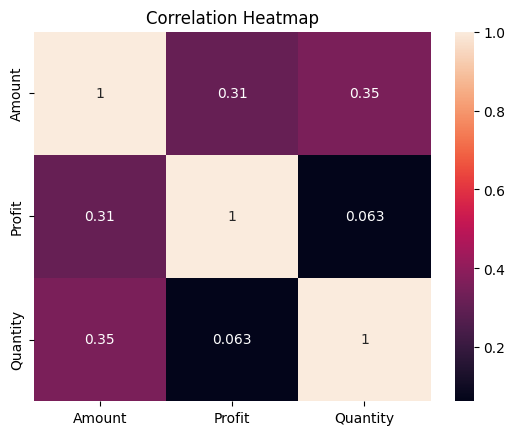

In [23]:
#Correlation Heatmap
sns.heatmap(df[['Amount','Profit','Quantity']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

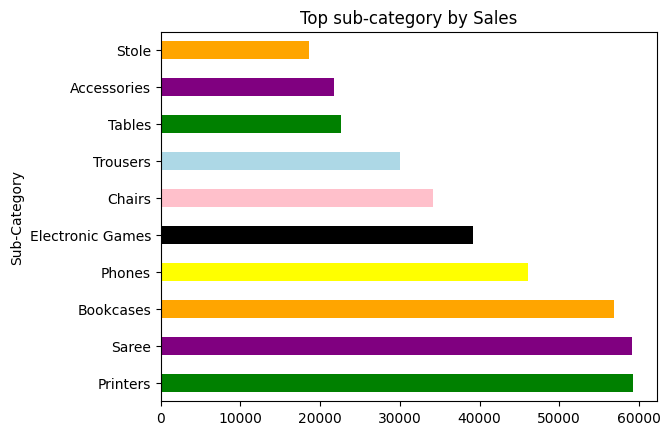

In [24]:
#TOP- SUB CATEGORIES
top_sub = df.groupby('Sub-Category')['Amount'].sum().sort_values(ascending=False).head(10)

top_sub.plot(kind='barh', color=['green', 'purple' ,'orange' ,'yellow','black','pink','lightblue'])
plt.title('Top sub-category by Sales')
plt.show()

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
df = df.sort_values(by='Order Date')

In [28]:
df.to_csv('cleaned_myntra_dataset.csv',index=False)